# Run Experiments Notebook

This notebook mirrors `scripts/run_experiments.py` while exposing the experiments as clean notebook cells. Run the cells from top to bottom. `M4` depends on the trained `M3` model because it uses the ResNet18 feature extractor.


In [1]:
# Uncomment the next line in a fresh Colab runtime if dependencies are missing.
# %pip install -r requirements.txt

from __future__ import annotations

import os
import sys
from pathlib import Path


def locate_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "src" / "config.py").exists() and (candidate / "scripts" / "run_experiments.py").exists():
            return candidate
    raise FileNotFoundError("Could not locate the project root from the current working directory.")


PROJECT_ROOT = locate_project_root(Path.cwd().resolve())
os.chdir(PROJECT_ROOT)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")


Project root: C:\Users\hp\OneDrive\Documents\MY PROJECTS\deep-learning-projects\project-02


In [2]:
import pandas as pd
from IPython.display import Image, display

from src.config import EXPERIMENT_SPECS, REPORTS_DIR, SEED
from src.experiment_runner import (
    prepare_experiment_context,
    results_summary_frame,
    run_experiment,
    upsert_result,
    write_experiment_reports,
)
from src.utils.common import set_global_seed

set_global_seed(SEED)
context = prepare_experiment_context()
spec_map = {spec.name: spec for spec in EXPERIMENT_SPECS}
results = []

summary_columns = [
    "name",
    "family",
    "model_key",
    "n_steps",
    "val_accuracy",
    "test_accuracy",
    "test_f1_macro",
]


def show_result(result: dict[str, object]) -> None:
    display(pd.DataFrame([{key: result.get(key) for key in summary_columns}]))
    if result.get("history_path"):
        print(f"History plot: {result['history_path']}")
        display(Image(filename=result["history_path"]))
    print(f"Confusion matrix: {result['confusion_matrix_path']}")
    display(Image(filename=result["confusion_matrix_path"]))
    if result["family"] == "hybrid":
        print("Saved feature arrays:")
        print("  train:", result["feature_train_shape"], result["train_feature_path"])
        print("  val:", result["feature_val_shape"], result["val_feature_path"])
        print("  test:", result["feature_test_shape"], result["test_feature_path"])


def run_and_log(spec_name: str) -> dict[str, object]:
    global results
    result = run_experiment(spec_map[spec_name], context)
    results = upsert_result(results, result)
    selection_summary = write_experiment_reports(results)
    show_result(result)
    print(f"Stored {len(results)} result(s). Reports updated in {REPORTS_DIR}.")
    best_name = selection_summary["best_overall_model"]["name"] if selection_summary["best_overall_model"] else None
    print(f"Current best overall model: {best_name}")
    return result


print("Notebook context is ready.")
print(f"Train samples: {len(context.dataset_context.train_indices)}")
print(f"Validation samples: {len(context.dataset_context.val_indices)}")
print(f"Test samples: {len(context.dataset_context.test_base)}")
print(f"Device: {context.device}")


Files already downloaded and verified


Files already downloaded and verified


Notebook context is ready.
Train samples: 45000
Validation samples: 5000
Test samples: 10000
Device: cuda


## M1: LeNet-like CNN


,name,family,model_key,n_steps,val_accuracy,test_accuracy,test_f1_macro
0,m1_lenet_like,torch,lenet_like,3520,0.5762,0.584,0.583456


History plot: C:\Users\hp\OneDrive\Documents\MY PROJECTS\deep-learning-projects\project-02\outputs\figures\m1_lenet_like_history.png


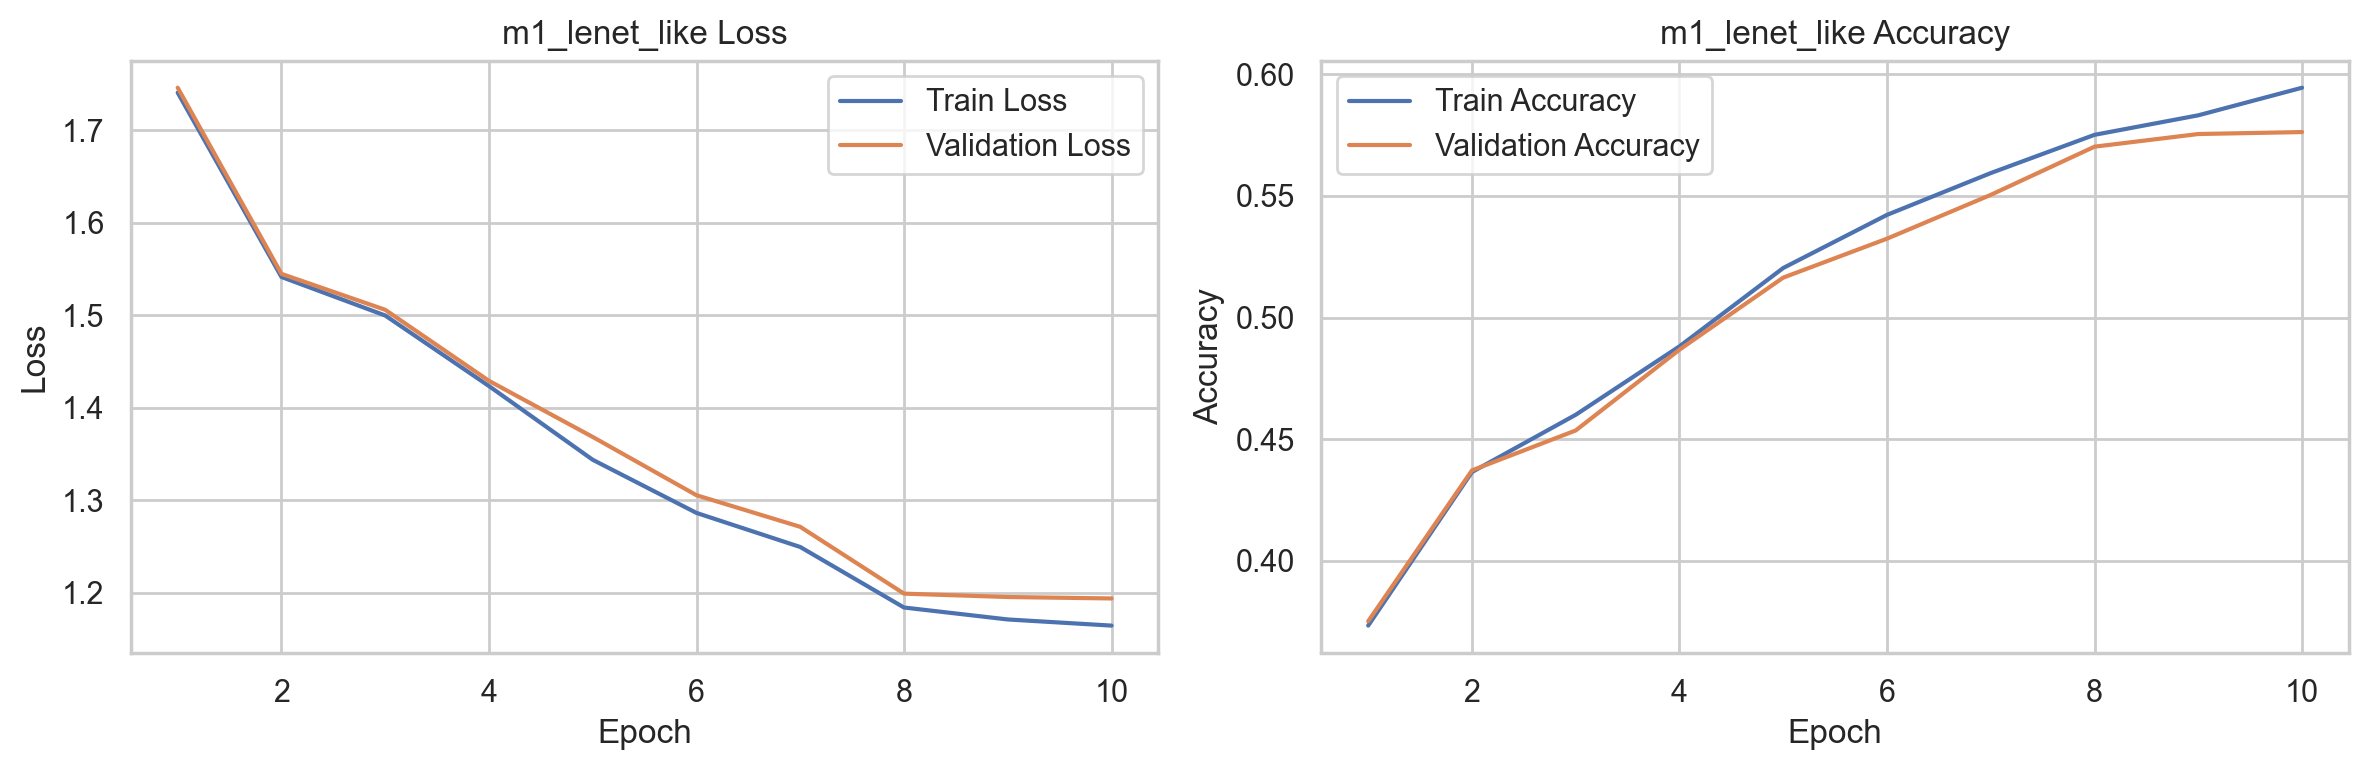

Confusion matrix: C:\Users\hp\OneDrive\Documents\MY PROJECTS\deep-learning-projects\project-02\outputs\figures\m1_lenet_like_confusion_matrix.png


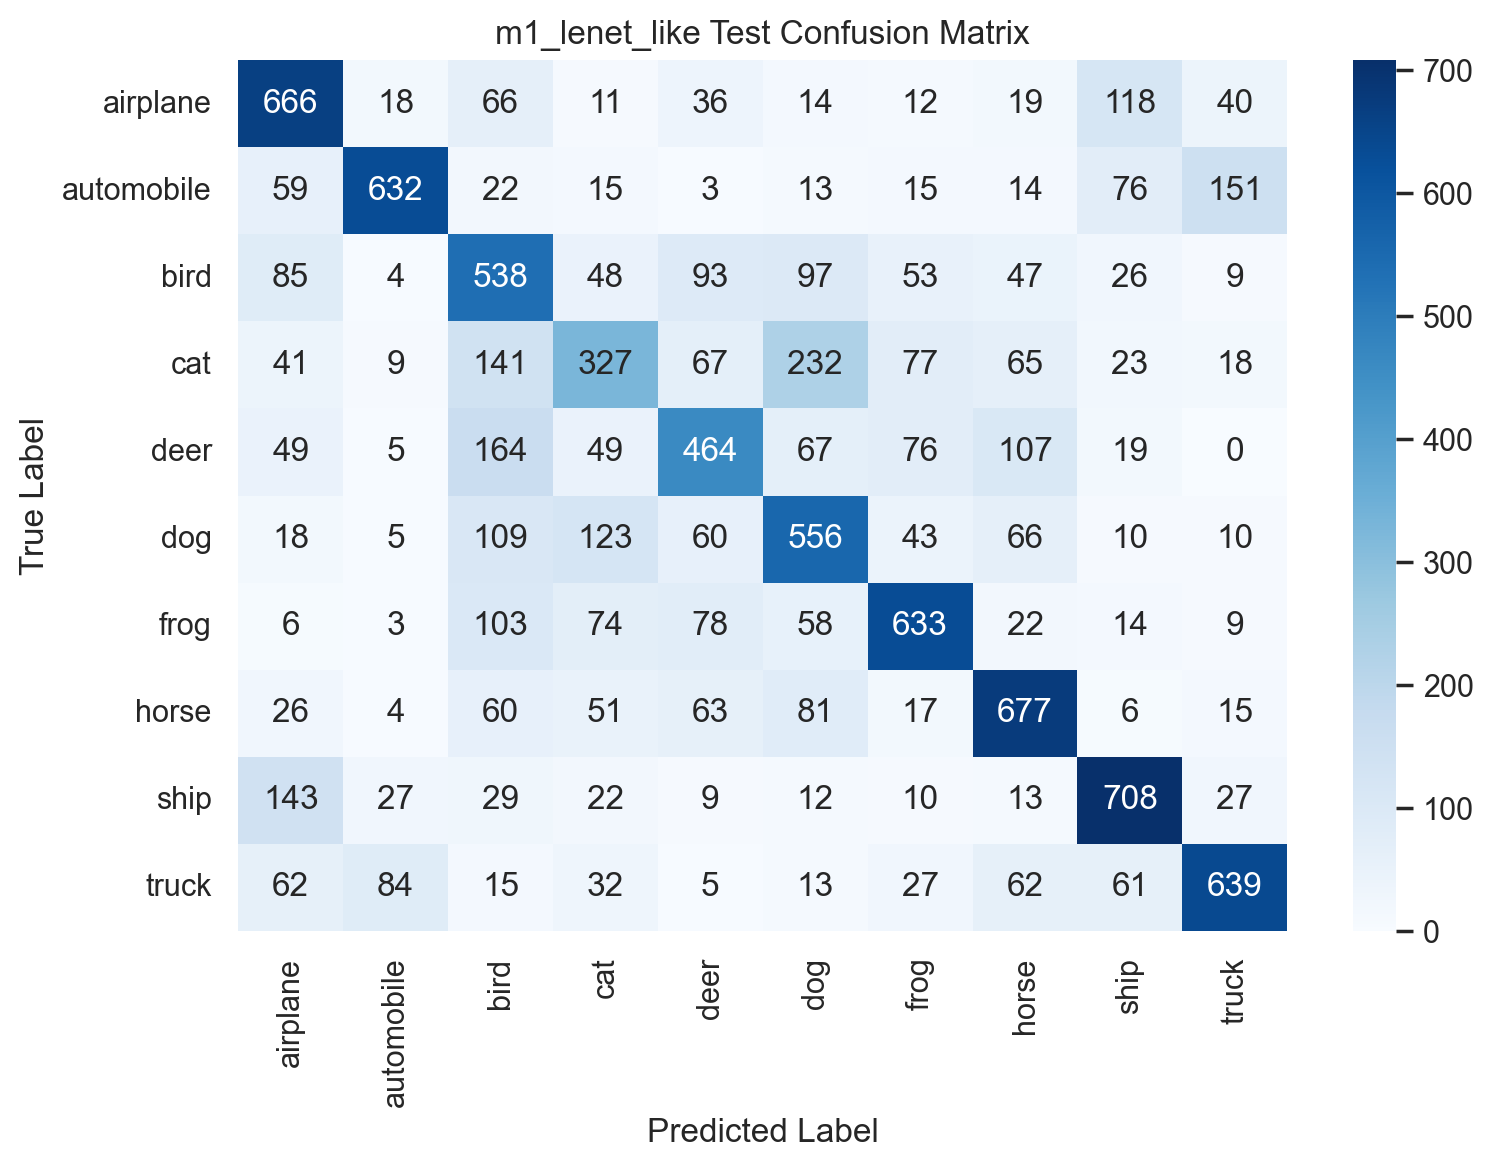

Stored 1 result(s). Reports updated in C:\Users\hp\OneDrive\Documents\MY PROJECTS\deep-learning-projects\project-02\outputs\reports.
Current best overall model: m1_lenet_like


In [3]:
m1_result = run_and_log("m1_lenet_like")


## M2: Improved CNN (BatchNorm + Dropout)


,name,family,model_key,n_steps,val_accuracy,test_accuracy,test_f1_macro
0,m2_improved_cnn,torch,improved_cnn,3520,0.6028,0.5998,0.593664


History plot: C:\Users\hp\OneDrive\Documents\MY PROJECTS\deep-learning-projects\project-02\outputs\figures\m2_improved_cnn_history.png


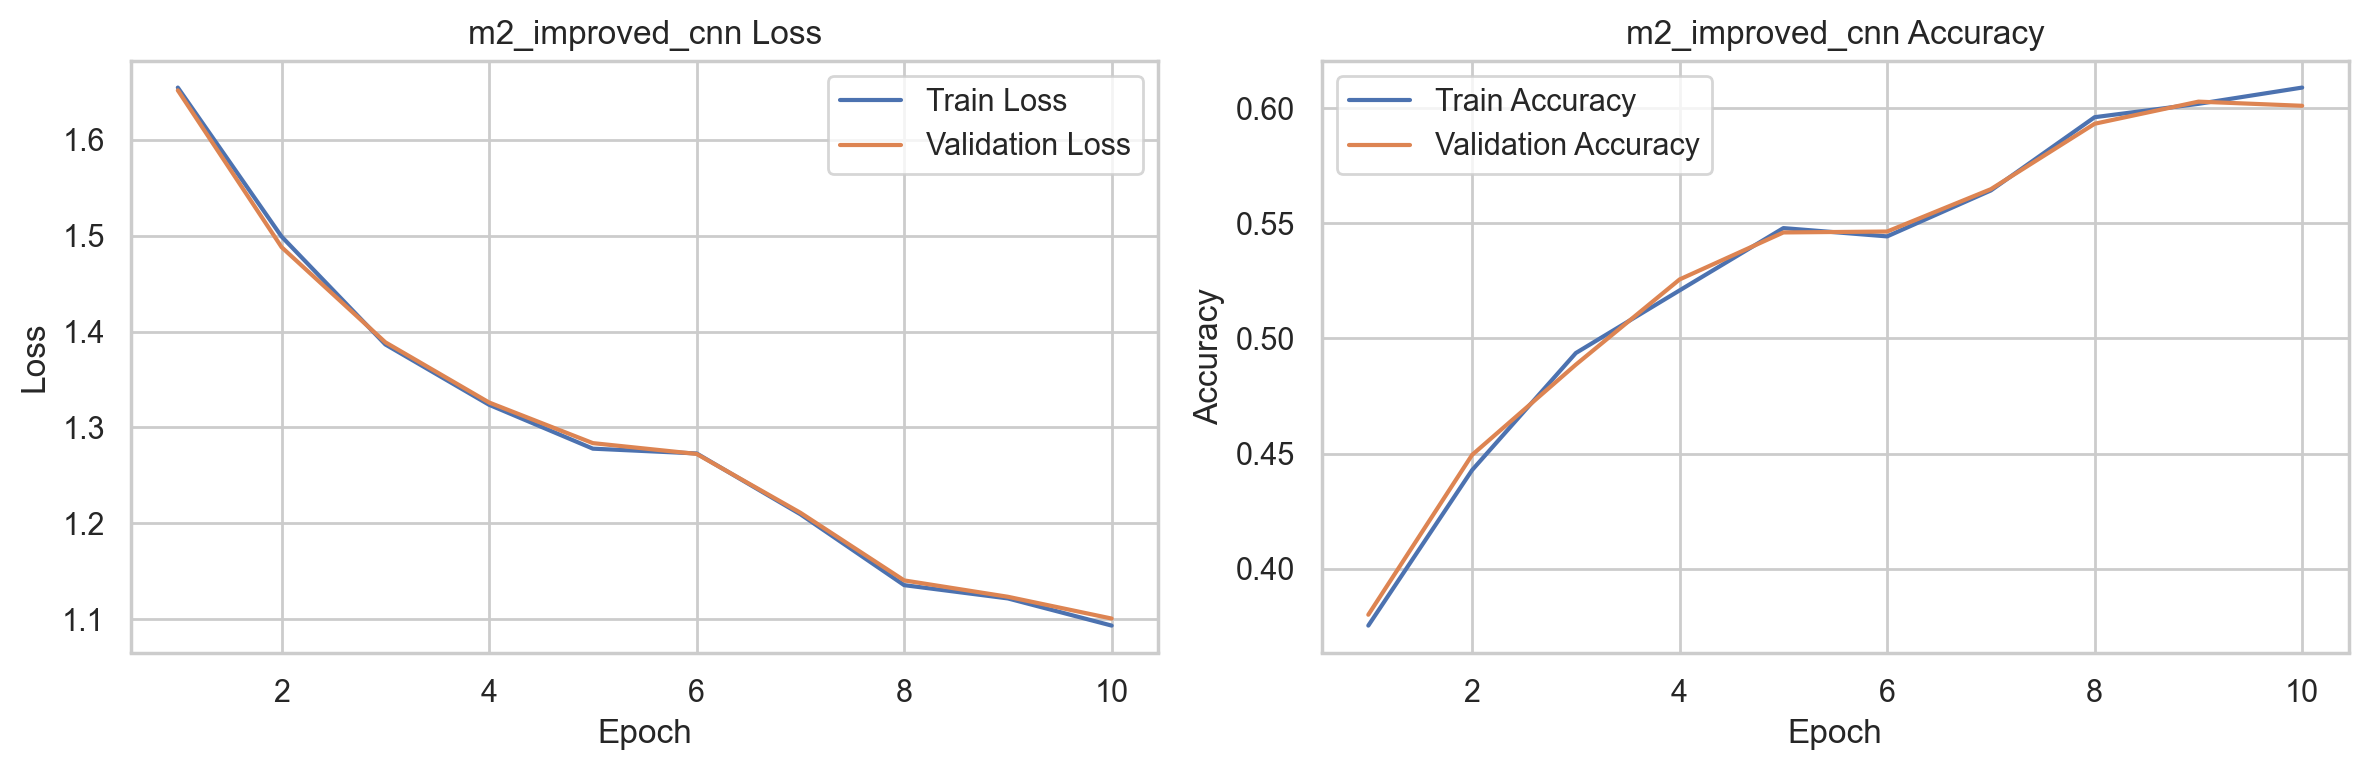

Confusion matrix: C:\Users\hp\OneDrive\Documents\MY PROJECTS\deep-learning-projects\project-02\outputs\figures\m2_improved_cnn_confusion_matrix.png


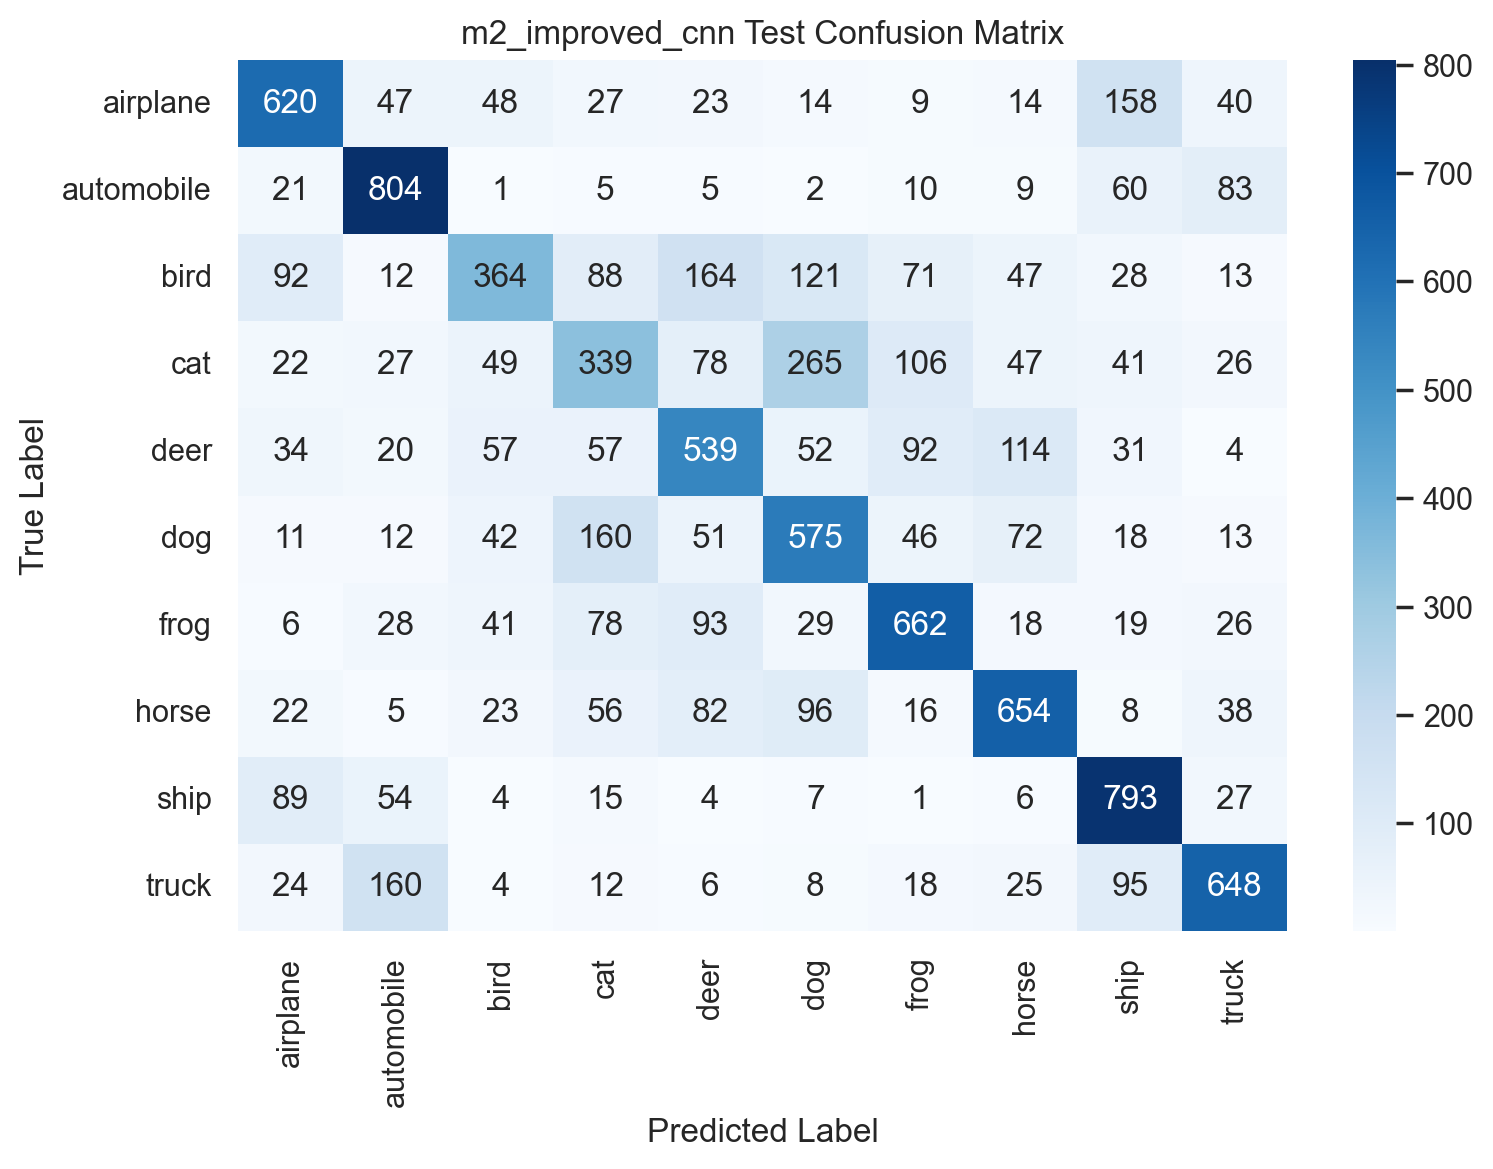

Stored 2 result(s). Reports updated in C:\Users\hp\OneDrive\Documents\MY PROJECTS\deep-learning-projects\project-02\outputs\reports.
Current best overall model: m2_improved_cnn


In [4]:
m2_result = run_and_log("m2_improved_cnn")


## M3: ResNet18


,name,family,model_key,n_steps,val_accuracy,test_accuracy,test_f1_macro
0,m3_resnet18,torch,resnet18,2816,0.919,0.9113,0.911614


History plot: C:\Users\hp\OneDrive\Documents\MY PROJECTS\deep-learning-projects\project-02\outputs\figures\m3_resnet18_history.png


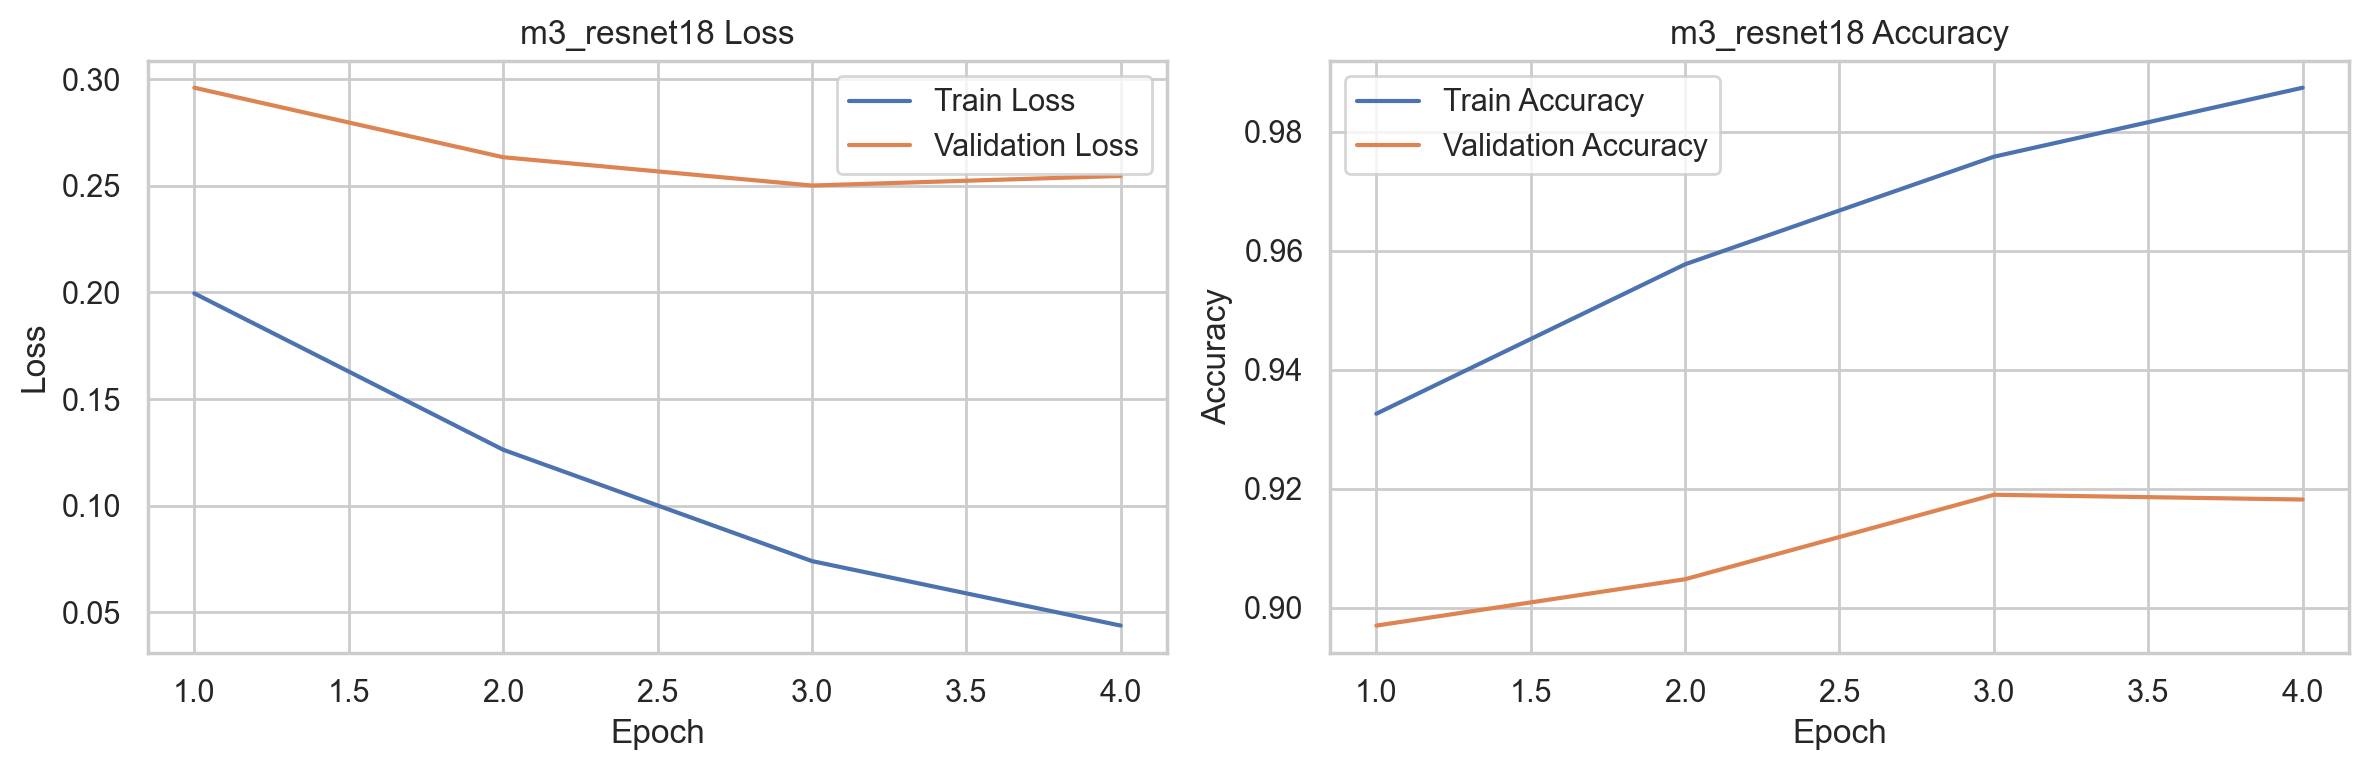

Confusion matrix: C:\Users\hp\OneDrive\Documents\MY PROJECTS\deep-learning-projects\project-02\outputs\figures\m3_resnet18_confusion_matrix.png


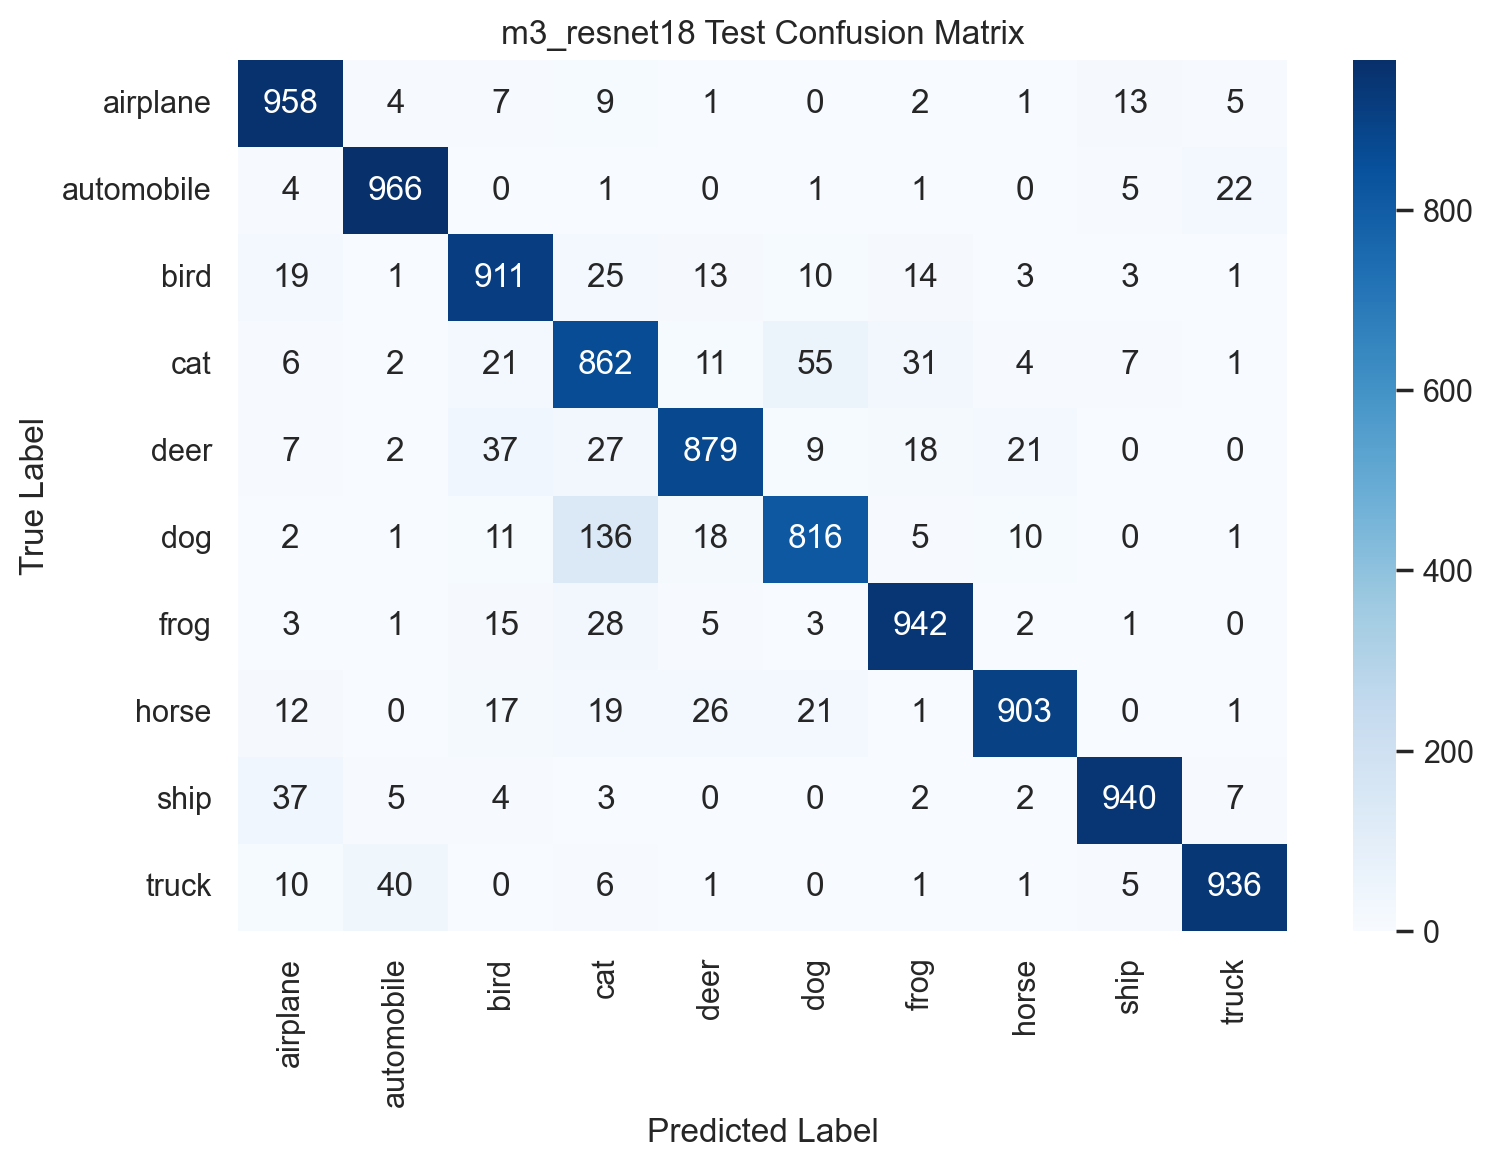

Stored 3 result(s). Reports updated in C:\Users\hp\OneDrive\Documents\MY PROJECTS\deep-learning-projects\project-02\outputs\reports.
Current best overall model: m3_resnet18


In [5]:
m3_result = run_and_log("m3_resnet18")


## M4: ResNet18 Feature Extractor + Linear SVM


,name,family,model_key,n_steps,val_accuracy,test_accuracy,test_f1_macro
0,m4_resnet18_linear_svm_hybrid,hybrid,linear_svm_hybrid,1,0.9112,0.9037,0.903763


Confusion matrix: C:\Users\hp\OneDrive\Documents\MY PROJECTS\deep-learning-projects\project-02\outputs\figures\m4_resnet18_linear_svm_hybrid_confusion_matrix.png


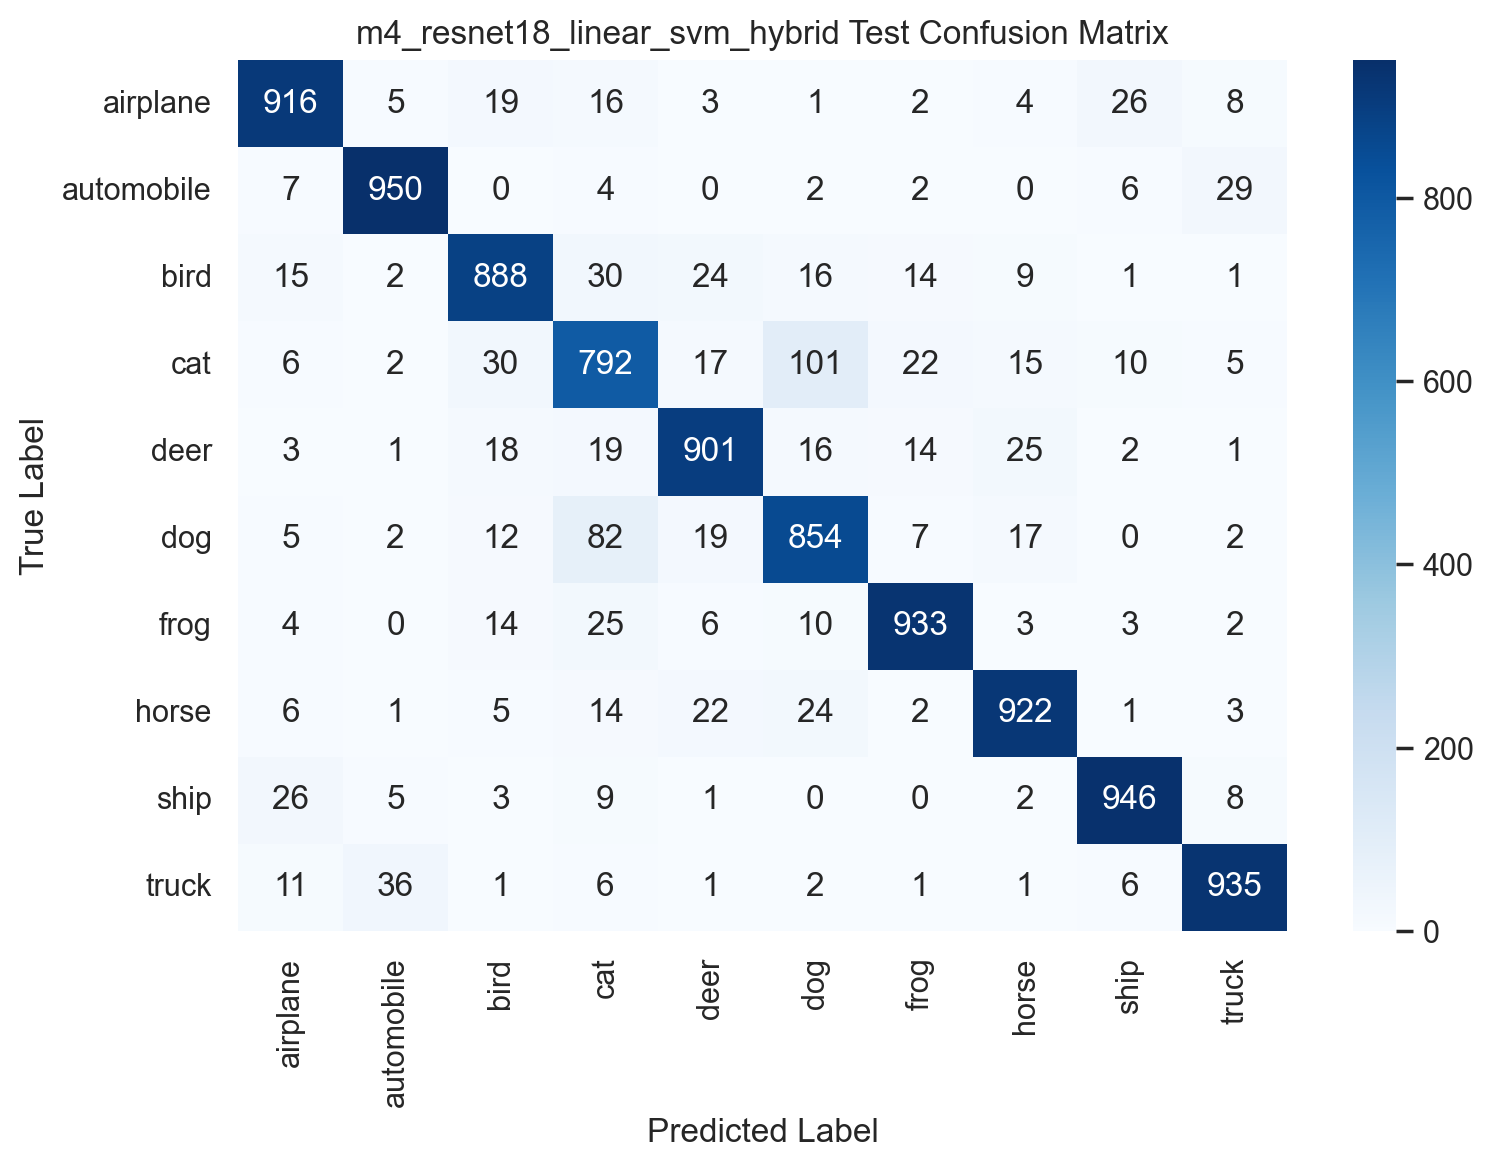

Saved feature arrays:
  train: [45000, 512] C:\Users\hp\OneDrive\Documents\MY PROJECTS\deep-learning-projects\project-02\outputs\features\train_features.npy
  val: [5000, 512] C:\Users\hp\OneDrive\Documents\MY PROJECTS\deep-learning-projects\project-02\outputs\features\val_features.npy
  test: [10000, 512] C:\Users\hp\OneDrive\Documents\MY PROJECTS\deep-learning-projects\project-02\outputs\features\test_features.npy
Stored 4 result(s). Reports updated in C:\Users\hp\OneDrive\Documents\MY PROJECTS\deep-learning-projects\project-02\outputs\reports.
Current best overall model: m3_resnet18


In [6]:
m4_result = run_and_log("m4_resnet18_linear_svm_hybrid")


## Final Summary and Comparison Plot


,name,family,model_key,loader_key,n_steps,val_accuracy,test_accuracy,test_f1_macro
0,m1_lenet_like,torch,lenet_like,custom,3520,0.5762,0.5840,0.583456
1,m2_improved_cnn,torch,improved_cnn,custom,3520,0.6028,0.5998,0.593664
2,m3_resnet18,torch,resnet18,pretrained,2816,0.9190,0.9113,0.911614
3,m4_resnet18_linear_svm_hybrid,hybrid,linear_svm_hybrid,pretrained,1,0.9112,0.9037,0.903763


Reports written to: C:\Users\hp\OneDrive\Documents\MY PROJECTS\deep-learning-projects\project-02\outputs\reports


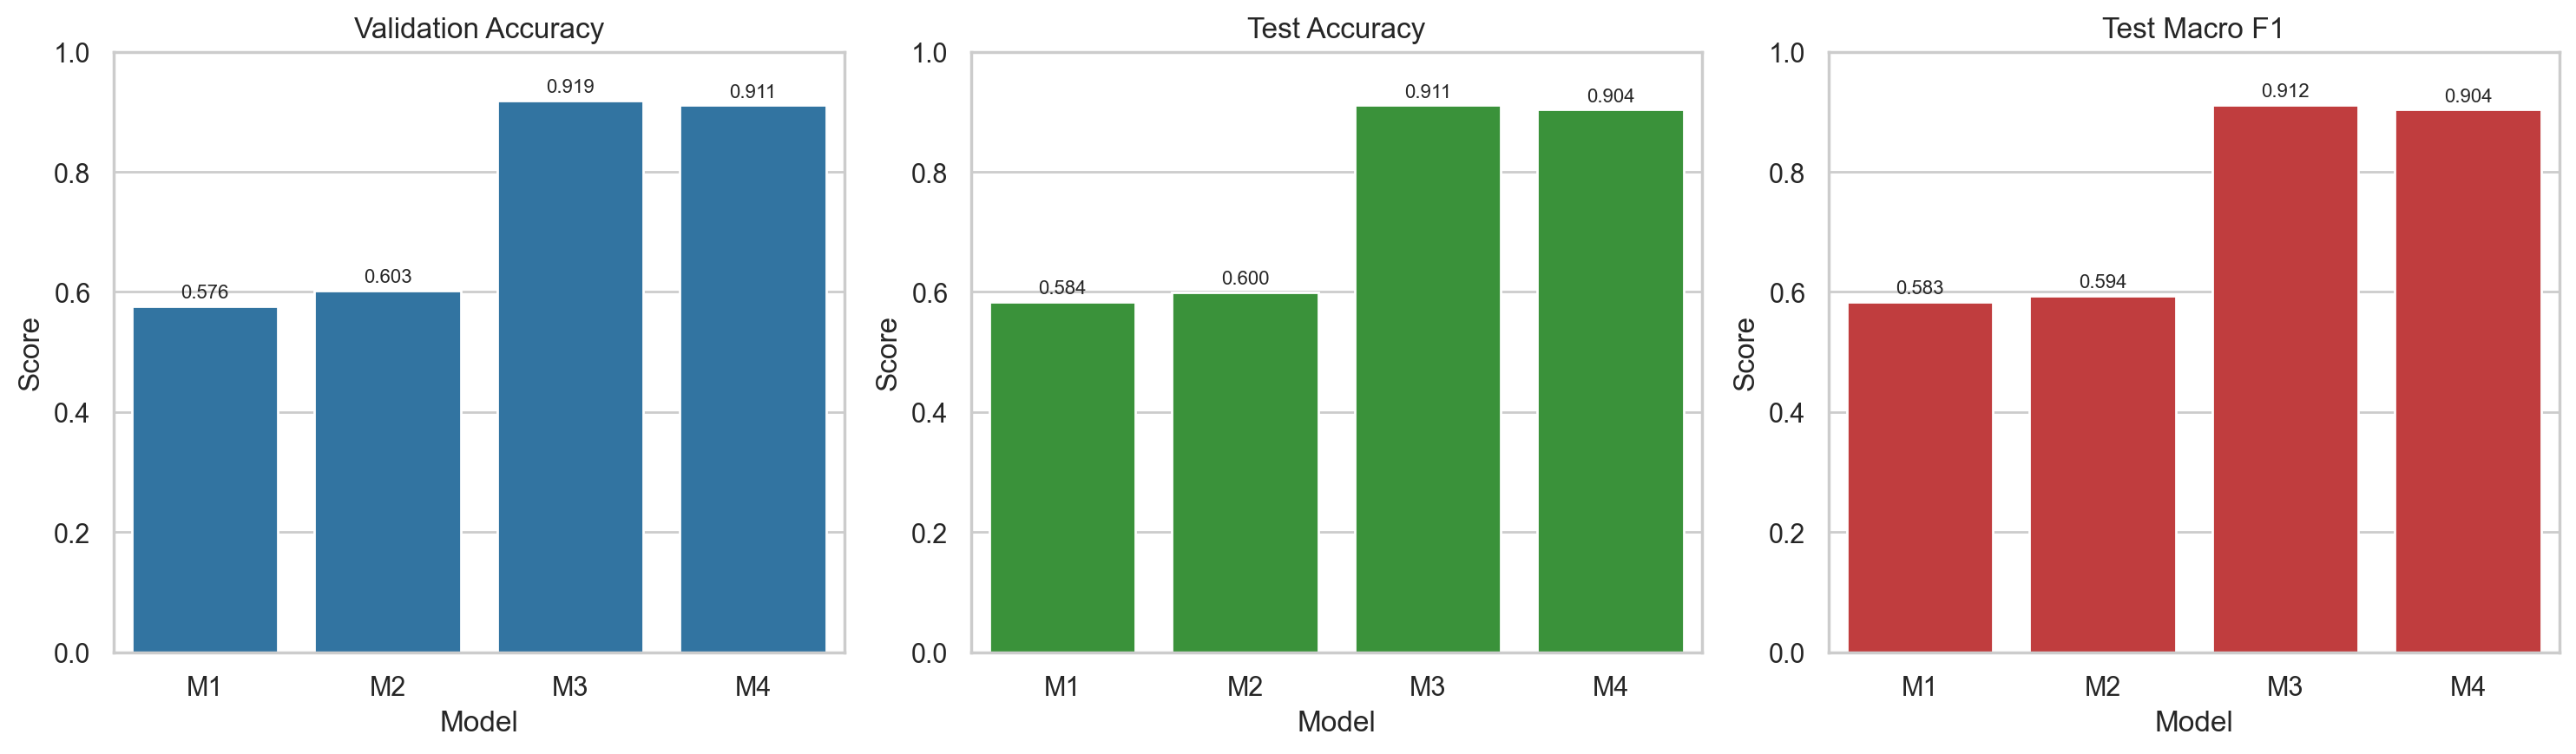

{'selection_rule': 'Highest validation accuracy wins; ties are resolved with lower n_steps.',
 'best_overall_model': {'name': 'm3_resnet18',
  'family': 'torch',
  'model_key': 'resnet18',
  'loader_key': 'pretrained',
  'batch_size': 64,
  'epochs': 4,
  'optimizer': 'sgd',
  'learning_rate': 0.005,
  'weight_decay': 0.0001,
  'momentum': 0.9,
  'feature_reference': None,
  'svm_c': None,
  'notes': 'Torchvision ResNet18 with ImageNet weights and partial fine-tuning.',
  'device': 'cuda',
  'n_steps': 2816,
  'val_loss': None,
  'val_accuracy': 0.919,
  'val_precision_macro': 0.9225754463153277,
  'val_recall_macro': 0.9190000000000002,
  'val_f1_macro': 0.91977737802452,
  'test_loss': None,
  'test_accuracy': 0.9113,
  'test_precision_macro': 0.9132663168148941,
  'test_recall_macro': 0.9113,
  'test_f1_macro': 0.9116140855681725,
  'final_train_accuracy': 0.9874444444444445,
  'final_val_accuracy': 0.9182,
  'history_path': WindowsPath('C:/Users/hp/OneDrive/Documents/MY PROJECTS/de

In [7]:
summary_frame = results_summary_frame(results)
display(summary_frame)

selection_summary = write_experiment_reports(results)
print(f"Reports written to: {REPORTS_DIR}")
display(Image(filename="outputs/figures/model_metric_comparison.png"))

selection_summary
